In [87]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import seaborn as sb
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize, sent_tokenize
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import pickle

In [3]:
df = pd.read_csv(r"C:\Users\Sufiyan\Downloads\Datasets\spam.csv", encoding='latin1')

In [4]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


### Data Cleaning

In [5]:
# handle Missing Values
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [6]:
df = df[['v2' , 'v1']]

In [7]:
df.head()

,v2,v1
0,"Go until jurong point, crazy.. Available only ...",ham
1,Ok lar... Joking wif u oni...,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam
3,U dun say so early hor... U c already then say...,ham
4,"Nah I don't think he goes to usf, he lives aro...",ham


In [8]:
# Rename the Columns Name
df.rename(columns={'v2' : 'text', 'v1' : 'target'}, inplace=True)

In [9]:

df.head()

,text,target
0,"Go until jurong point, crazy.. Available only ...",ham
1,Ok lar... Joking wif u oni...,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam
3,U dun say so early hor... U c already then say...,ham
4,"Nah I don't think he goes to usf, he lives aro...",ham


In [10]:
# Apply labelEncoding to Target Column
encoder = LabelEncoder()

In [11]:
df['target'] = encoder.fit_transform(df['target'])

In [12]:
df.head()

,text,target
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0


In [13]:
# Handle Missing Values
df.isnull().sum()

text      0
target    0
dtype: int64

In [14]:
# Handle Duplicates Values
df.duplicated().sum()

np.int64(403)

In [15]:
df.drop_duplicates(keep="first", inplace=True)

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.head()

,text,target
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0


### EDA (Exploratery Data Analysis)

In [18]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

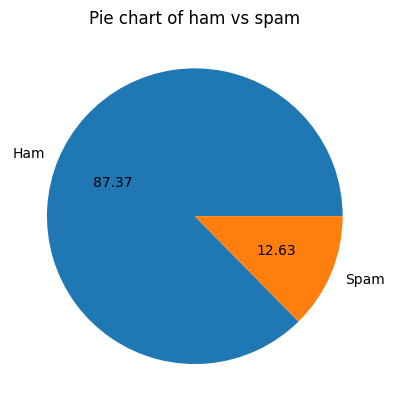

In [19]:
plt.pie(df['target'].value_counts(), labels=["Ham","Spam"], autopct="%.2f")
plt.title("Pie chart of ham vs spam")
plt.show()

In [20]:
df['num_characters'] = df['text'].apply(len)

In [21]:
df['num_words'] = df['text'].apply(lambda x: len(word_tokenize(x)))

In [22]:
df["num_sentences"] = df['text'].apply(lambda x: len(sent_tokenize(x)))

In [23]:
df.head()

,text,target,num_characters,num_words,num_sentences
0,"Go until jurong point, crazy.. Available only ...",0,111,24,2
1,Ok lar... Joking wif u oni...,0,29,8,2
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,37,2
3,U dun say so early hor... U c already then say...,0,49,13,1
4,"Nah I don't think he goes to usf, he lives aro...",0,61,15,1


In [24]:
df[df['target'] == 0][["num_characters", "num_words" , "num_sentences"]].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [25]:
df[df['target'] == 1][["num_characters", "num_words" , "num_sentences"]].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


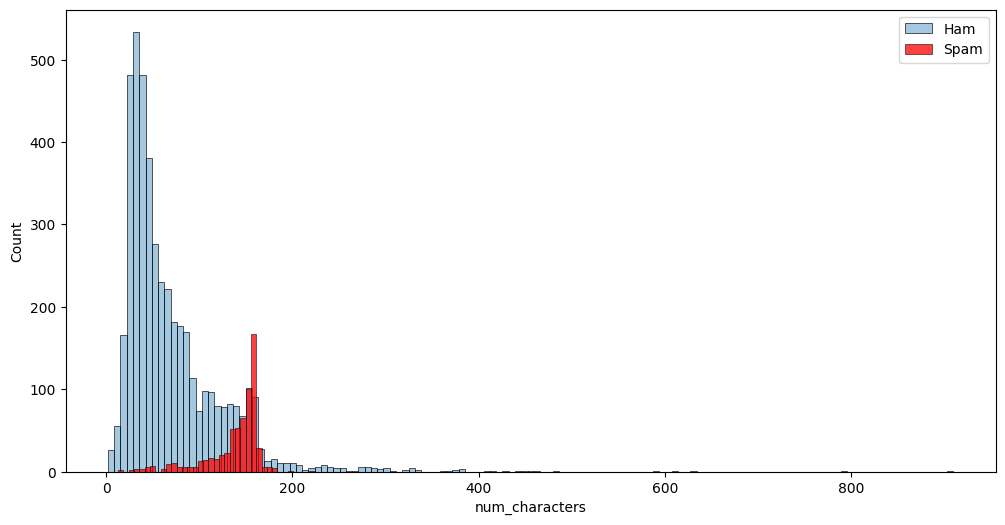

In [26]:
plt.figure(figsize=(12,6))
sb.histplot(df[df['target'] == 0]["num_characters"],label="Ham", alpha=0.4)
sb.histplot(df[df['target'] == 1]["num_characters"],color="red",label="Spam")
plt.legend()
plt.show()

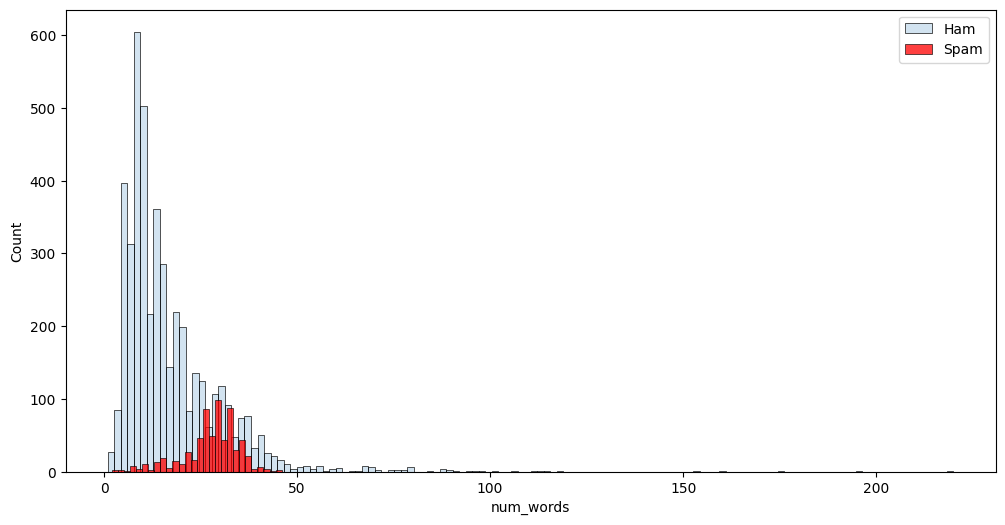

In [27]:
plt.figure(figsize=(12,6))
sb.histplot(df[df['target'] == 0]["num_words"],label="Ham", alpha=0.2)
sb.histplot(df[df['target'] == 1]["num_words"],color="red",label="Spam")
plt.legend()
plt.show()

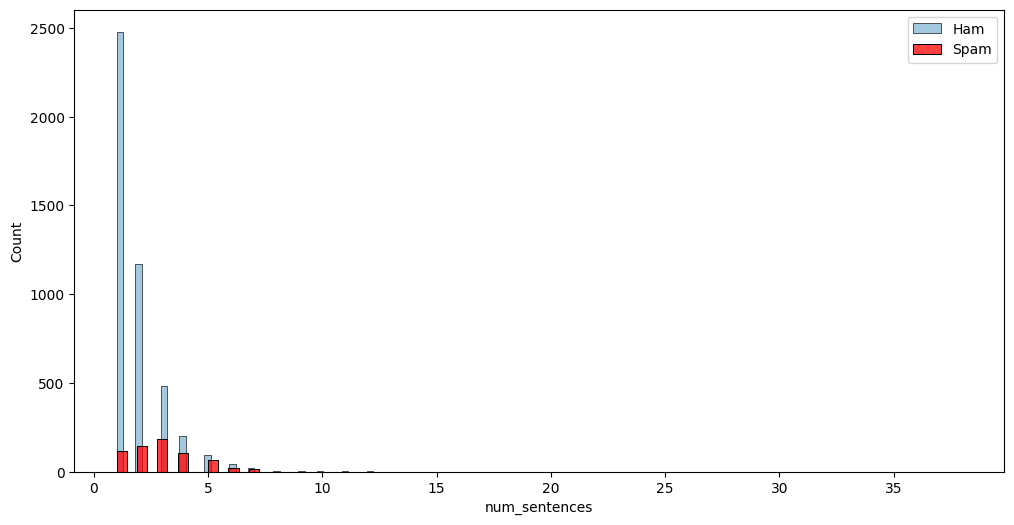

In [28]:
plt.figure(figsize=(12,6))
sb.histplot(df[df['target'] == 0]["num_sentences"],label="Ham", alpha=0.4)
sb.histplot(df[df['target'] == 1]["num_sentences"],color="red",label="Spam")
plt.legend()
plt.show()

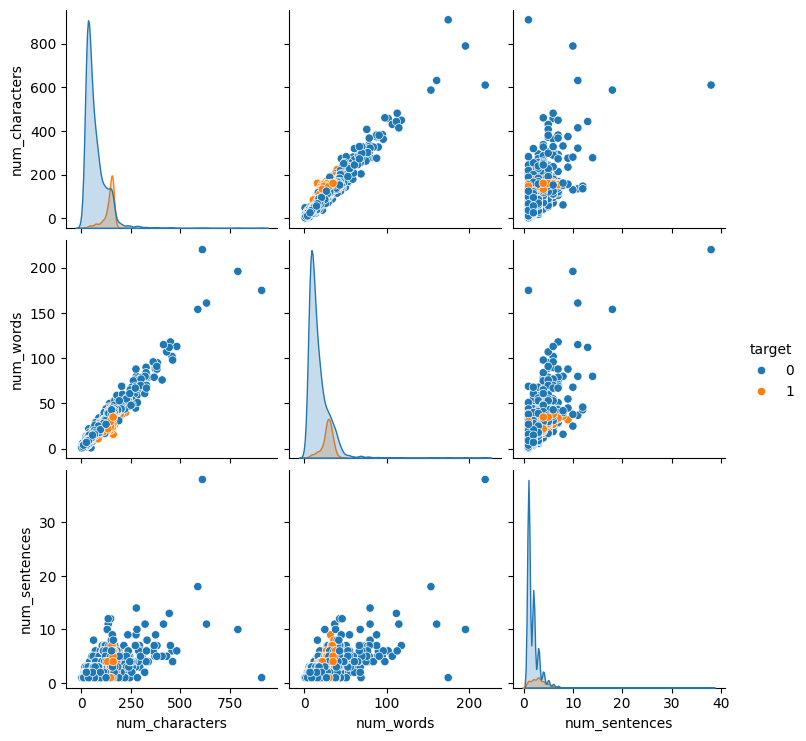

In [29]:
sb.pairplot(df, hue="target")
plt.show()

<Axes: >

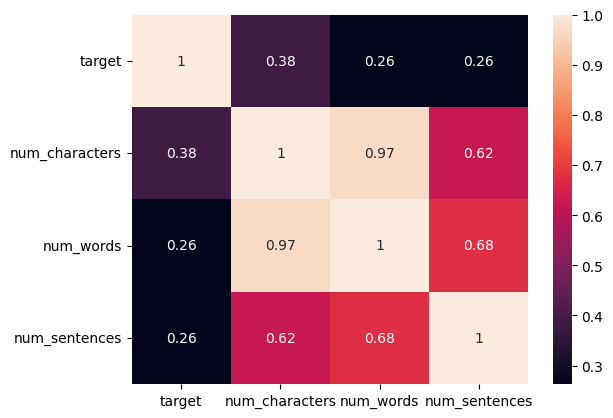

In [30]:
sb.heatmap(df.corr(numeric_only=True), annot=True)

In [31]:
print(df['num_characters'].values)

[111  29 155 ...  57 125  26]


### Data Preprocessing

* Lower case
* Tokenize
* Removing Special Character
* Removing Stopwords and punctuation
* Stemming

In [32]:
ps = PorterStemmer()
def transform_text(text):
    text = text.lower()
    text = word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    text = y.copy()
    y.clear()

    for i in text:
        if i not in stopwords.words("english") and string.punctuation:
            y.append(i)
    text = y.copy()
    y.clear()
    for i in text:
        y.append(ps.stem(i))
    return " ".join(y)

In [33]:
df["transformed_text"] = df['text'].apply(transform_text)

In [34]:
df.head()

,text,target,num_characters,num_words,num_sentences,transformed_text
0,"Go until jurong point, crazy.. Available only ...",0,111,24,2,go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,0,29,8,2,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,0,49,13,1,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",0,61,15,1,nah think goe usf live around though


In [35]:
wc = WordCloud(height=1200, width=2400, min_font_size=10, background_color="black")

In [36]:
ham_msg = wc.generate(df[df['target'] == 0]["transformed_text"].astype(str).str.cat(sep=" "))
spam_msg = wc.generate(df[df['target'] == 1]["transformed_text"].astype(str).str.cat(sep=" "))

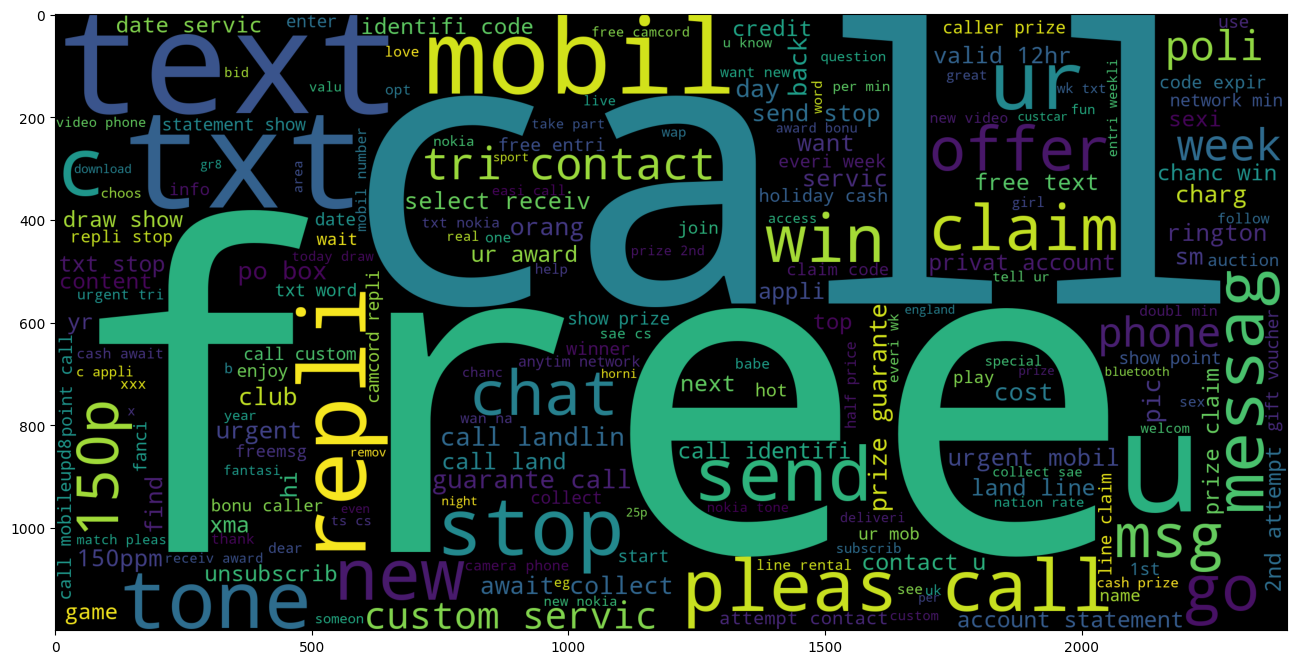

In [37]:
plt.figure(figsize=(16,8))
plt.imshow(ham_msg)

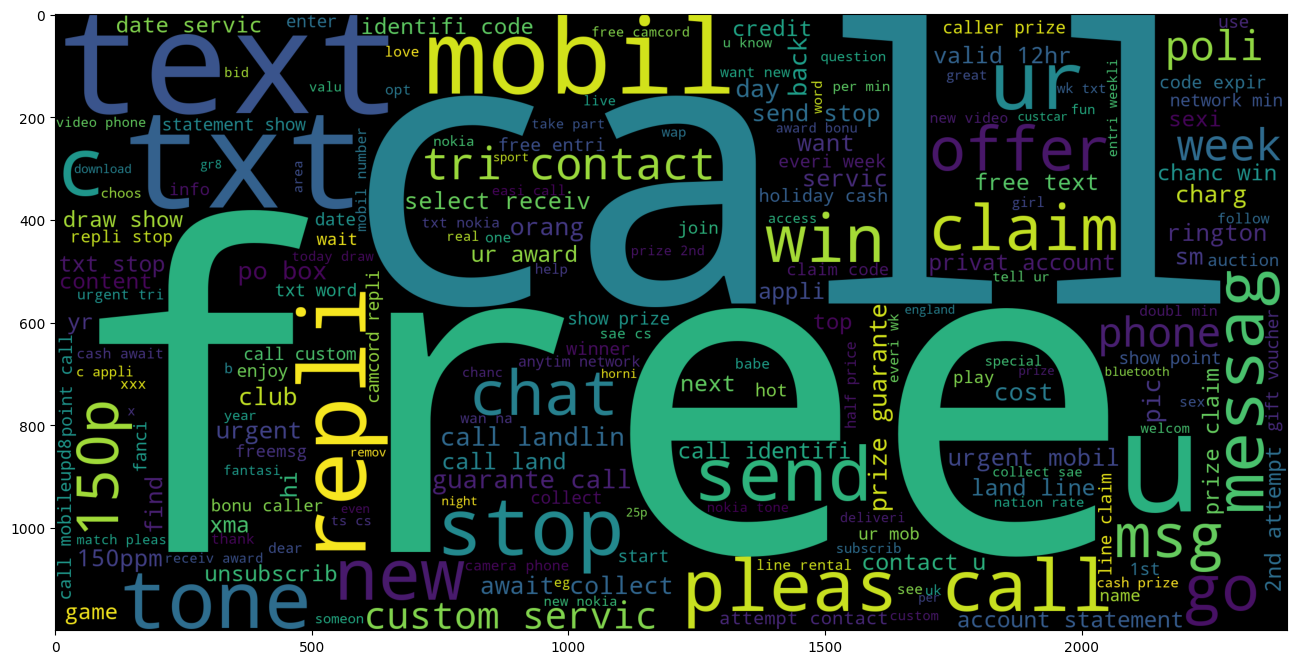

In [38]:
plt.figure(figsize=(16,8))
plt.imshow(spam_msg)

In [39]:
spam_word = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_word.append(word)   

In [40]:
from collections import Counter

In [41]:
msgs = pd.DataFrame(Counter(spam_word).most_common(n=50))

C:\Users\Sufiyan\AppData\Local\Temp\ipykernel_3928\78890549.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x=msgs[0].values, y=msgs[1].values, palette="winter")


Text(0, 0.5, 'Count')

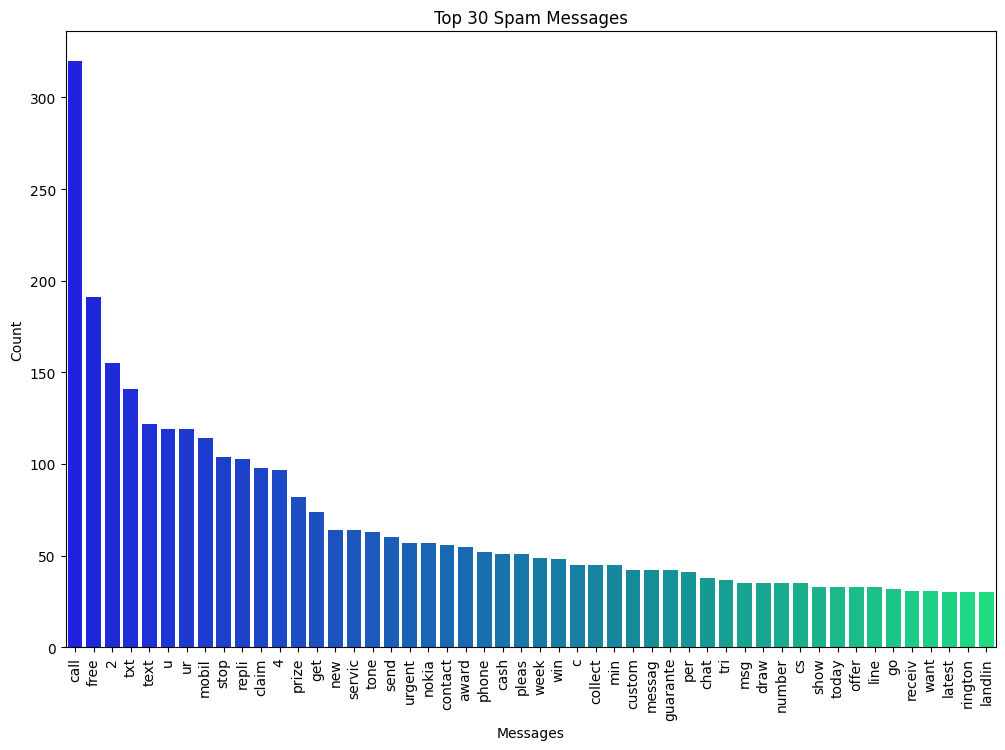

In [42]:
plt.figure(figsize=(12,8))
sb.barplot(x=msgs[0].values, y=msgs[1].values, palette="winter")
plt.xticks(rotation="vertical")
plt.title("Top 30 Spam Messages")
plt.xlabel("Messages")
plt.ylabel("Count")

C:\Users\Sufiyan\AppData\Local\Temp\ipykernel_3928\3859763912.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x=ham_msgs[0].values, y=ham_msgs[1].values, palette="winter")


Text(0, 0.5, 'Count')

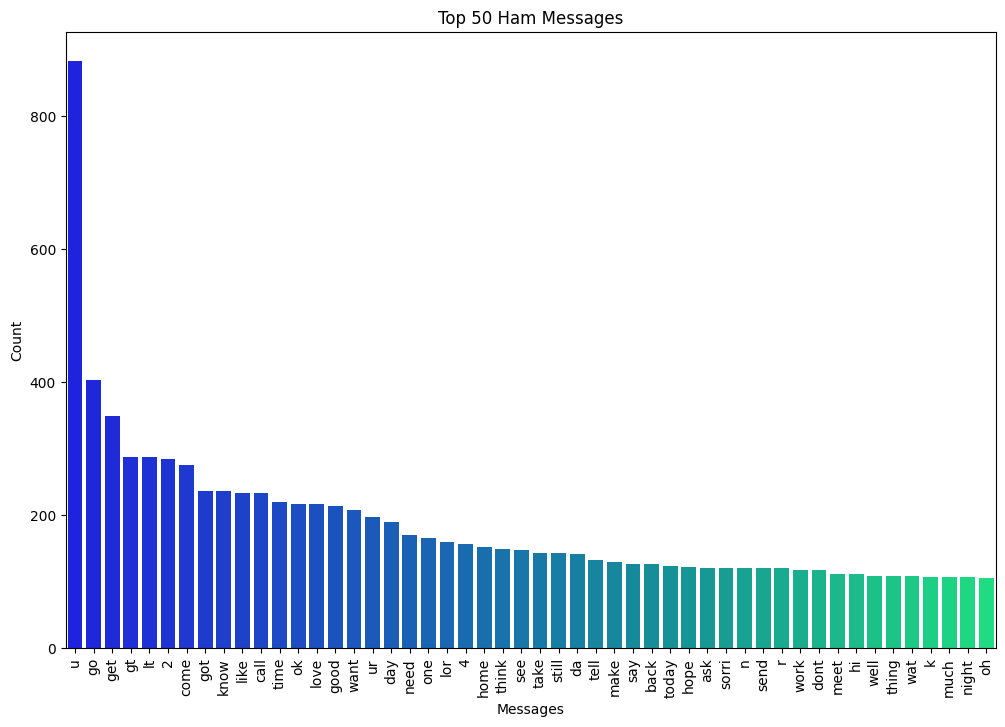

In [43]:
ham_word = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_word.append(word)   
ham_msgs = pd.DataFrame(Counter(ham_word).most_common(n=50))
plt.figure(figsize=(12,8))
sb.barplot(x=ham_msgs[0].values, y=ham_msgs[1].values, palette="winter")
plt.xticks(rotation="vertical")
plt.title("Top 50 Ham Messages")
plt.xlabel("Messages")
plt.ylabel("Count")

In [57]:
tf = TfidfVectorizer(max_features=3000)

In [58]:
X = tf.fit_transform(df['transformed_text']).toarray()

In [59]:
y = df['target'].values

In [60]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2 , random_state=2)

In [61]:
gnb = GaussianNB()
bnb = BernoulliNB()
mnb = MultinomialNB()

In [62]:
gnb.fit(x_train, y_train)
y_pred1 = gnb.predict(x_test)
print("Accuracy Score : ", accuracy_score(y_test, y_pred1))
print("Confusion Metrix : \n", confusion_matrix(y_test, y_pred1))
print("Precision : ", precision_score(y_test, y_pred1))

Accuracy Score :  0.874274661508704
Confusion Metrix : 
 [[790 106]
 [ 24 114]]
Precision :  0.5181818181818182


In [63]:
mnb.fit(x_train, y_train)
y_pred2 = mnb.predict(x_test)
print("Accuracy Score : ", accuracy_score(y_test, y_pred2))
print("Confusion Metrix : \n", confusion_matrix(y_test, y_pred2))
print("Precision : ", precision_score(y_test, y_pred2))

Accuracy Score :  0.9709864603481625
Confusion Metrix : 
 [[896   0]
 [ 30 108]]
Precision :  1.0


In [74]:
bnb.fit(x_train, y_train)
y_pred3 = bnb.predict(x_test)
print("Accuracy Score : ", accuracy_score(y_test, y_pred3))
print("Confusion Metrix : \n", confusion_matrix(y_test, y_pred3))
print("Precision : ", precision_score(y_test, y_pred3))

Accuracy Score :  0.9835589941972921
Confusion Metrix : 
 [[895   1]
 [ 16 122]]
Precision :  0.991869918699187


In [89]:
svc = SVC(kernel="sigmoid", gamma=1.0, probability=True)
mnb = MultinomialNB()
bnb = BernoulliNB()
rfc = RandomForestClassifier(n_estimators=50, random_state=2)

In [90]:
voting = VotingClassifier(estimators=[('mnb', mnb), ("bnb", bnb), ("rfc", rfc)], voting="soft")

In [91]:
voting.fit(x_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('mnb', ...), ('bnb', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0


In [92]:
y_pred = voting.predict(x_test)

In [93]:
print("Accuracy Score ", accuracy_score(y_test, y_pred))
print(f"Confusion Matrix : \n{confusion_matrix(y_test, y_pred)}")
print(f"Precision Score : {precision_score(y_test, y_pred)}")

Accuracy Score  0.9825918762088974
Confusion Matrix : 
[[896   0]
 [ 18 120]]
Precision Score : 1.0


In [95]:
pickle.dump(tf,open("Vectorizer.pkl", "wb"))
pickle.dump(voting,open("model.pkl","wb"))
